# Prédiction de la survie des passagers du Titanic avec k-NN

Dans ce notebook, nous utilisons notre package `package_knn` pour appliquer l’algorithme des **k-plus proches voisins (k-NN)**.  
L’objectif est de prédire si un passager a survécu ou non en fonction de ses caractéristiques (âge, sexe, classe, etc.).  

Nous évaluons ensuite la performance du modèle à l’aide de l’**accuracy**, qui mesure le pourcentage de bonnes prédictions.

## Imports

In [1]:
# Import de notre package personnalisé:
from package_knn import KNN, accuracy_score, find_k_optimal
from sklearn.preprocessing import LabelEncoder

# Imports classiques:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

## Chargement et aperçu des données:

In [2]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Prétraitement, entraînement et évaluation:

In [3]:
# Supprimer les colonnes inutiles
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Gérer les valeurs manquantes
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())  # Remplacer les âges manquants par la médiane
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])  # Remplacer 'Embarked' par le mode

# Encoder les variables catégoriques
label_encoder = LabelEncoder()
titanic['Sex'] = label_encoder.fit_transform(titanic['Sex'])  # 0 pour female, 1 pour male
titanic = pd.get_dummies(titanic, columns=['Embarked'], drop_first=True)  # One-hot encoding pour 'Embarked'

# Définir X (caractéristiques) et y (cible)
X = titanic.drop(columns=['Survived']).values  # Convertir en numpy array
y = titanic['Survived'].values  # Convertir en numpy array

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
# --- Entraîner le modèle KNN ---
# Initialiser le modèle KNN
knn = KNN(K=16, metric='euclidean')  # essayer différentes valeurs de K ou 'manhattan' comme métrique

# Entraîner le modèle
knn.fit(X_train, y_train)

# Prédire sur l'ensemble de test
y_pred = knn.predict(X_test)

# --- Évaluer le modèle ---
# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of kNN model on Titanic data: {accuracy:.4f}")

Accuracy of kNN model on Titanic data: 0.7542


## Recherche de la valeur optimale de K

Nous utilisons la fonction `find_k_optimal` de notre package pour tester différentes valeurs de K et déterminer celle qui maximise l’accuracy sur l’ensemble de test.  

> Note : sur ce dataset, la valeur optimale trouvée est K=10, avec une accuracy d’environ 0.75.

Optimal value of k (with euclidean metric): 16


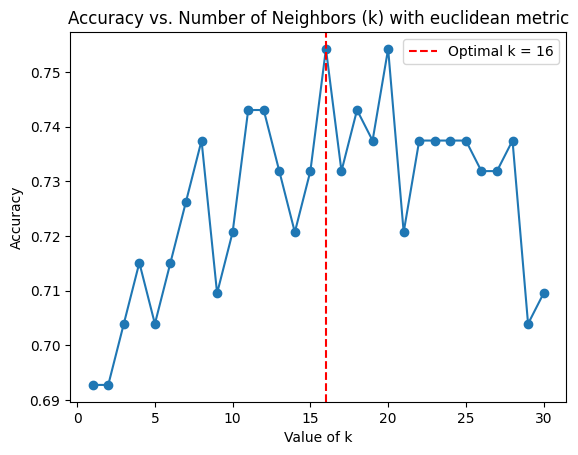

Optimal k value: 16


In [5]:
k_opt = find_k_optimal(X_train, X_test, y_train, y_test)
print("Optimal k value:", k_opt)